# Unified Poisson Solver Testing
This notebook runs the unified test suites for Problem 1 (Table 1 & 2) as well as the complete NUDFT/NUFFT Accuracy Comparisons, tracking strictly $L_2$ relative errors and computational runtimes.

In [1]:
import os, sys
import pandas as pd
# Main project root
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.CPU.testing_helpers import (
    run_tests_pipeline,
    set_global_config,
    get_global_config,
    render_accuracy,
    render_runtime,
    render_table2_accuracy,
    render_table2_runtime,
    plot_accuracy_table1,
    plot_runtime_table1,
    plot_accuracy_table2,
    plot_runtime_table2,
    plot_accuracy_comparison,
    plot_runtime_comparison
)


c:\Users\charl\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup & Configurable Parameters
Configure domain radius, solver tolerances, Tikhonov regularization $\lambda$, equations/problems, and grid sweep resolutions.

In [2]:
# =============================================================================
# Domain & Solver Parameters
# =============================================================================
R = 1.0                     # Disk radius
RAD_UNIF = 1                # 1: Uniform radial grid
RADIAL_MAPPING = None       # Non-uniform radial mapping if RAD_UNIF == 0
# Solver Tolerances & Regularization (Lambda)
TOL_NUFFT = 1e-10           # CG residual tolerance for NUFFT
MAXITER_NUFFT = 100         # Maximum CG iterations (50-100 is optimal)
EPS_FINUFFT = 1e-12         # FINUFFT kernel precision (optimal W=10 width)
REG_PARAM = 1e-20           # Regularization parameter
QUAD_RULE = 1               # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1               # 1: Dirichlet, 2: Neumann


# =============================================================================
# Problem Selection
# =============================================================================
PROBLEM_TYPE = 0            # 0: Borges & Daripa Problem 1, 2: Problem 2
CUSTOM_PROBLEM = None
# Apply global configuration
set_global_config(
    R=R,
    rad_unif=RAD_UNIF,
    radial_mapping=RADIAL_MAPPING,
    tol_nufft=TOL_NUFFT,
    maxiter_nufft=MAXITER_NUFFT,
    eps_finufft=EPS_FINUFFT,
    reg_param=REG_PARAM,
    quad_rule=QUAD_RULE,
    BC_choice=BC_CHOICE,
    problem_type=PROBLEM_TYPE,
    custom_problem=CUSTOM_PROBLEM,
)

# =============================================================================
# Grid Sweep Resolutions
# =============================================================================
N_vals_p0 = [32, 64, 128, 256, 512]
M_vals_p0 = [32, 64, 128, 256, 512]
N_fixed_p0 = 32

N_vals_p1 = [32, 64, 128, 256, 512]
M_vals_p1 = [32, 64, 128, 256, 512]
N_fixed_p1 = 32

N_vals_p2 = [32, 64, 128, 256, 512]
M_vals_p2 = [32, 64, 128, 256, 512]
N_fixed_p2 = 32

N_vals_c = [32, 64, 128, 256, 512]
M_vals_c = [32, 64, 128, 256, 512]

MUTE_OUTPUT = True


# Run Problems

In [3]:
METHODS_P2 = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Fixed-stratified_rand-NUDFT", label="Fixed stratified / NUDFT", azu_unif=1, mesh_kind="stratified_rand", solver_azu_unif=1, use_nudft=True),
    dict(name="Fixed-stratified_rand-NUFFT", label="Fixed stratified / NUFFT", azu_unif=1, mesh_kind="stratified_rand", solver_azu_unif=1, use_nudft=False),
]

METHODS_COMP = [
    dict(name="Unif-FFT", label="Uniform / FFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=2, use_nudft=None),
    dict(name="Unif-NUDFT", label="Uniform / NUDFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=True),
    dict(name="Unif-NUFFT", label="Uniform / NUFFT", azu_unif=2, mesh_kind="uniform", solver_azu_unif=1, use_nudft=False),
]

# ONLY include slight nonuniform grids here
for kind in ("stratified_rand", "jittered"):
    METHODS_COMP += [
        dict(name=f"Fixed-{kind}-NUDFT", label=f"Fixed {kind} / NUDFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=True),
        dict(name=f"Fixed-{kind}-NUFFT", label=f"Fixed {kind} / NUFFT", azu_unif=1, mesh_kind=kind, solver_azu_unif=1, use_nudft=False),
    ]

print("\nRunning Problem 2 - Table 1 (Stratified Rand)...")
df_p2_t1 = run_tests_pipeline(N_vals_p2, M_vals_p2, fixed_other=None, methods=METHODS_P2, test_type="P1_Table1", mute=MUTE_OUTPUT)
print("\nRunning Problem 2 - Table 2 (Stratified Rand)...")
df_p2_t2 = run_tests_pipeline(None, M_vals_p2, fixed_other=N_fixed_p2, methods=METHODS_P2, test_type="P1_Table2", mute=MUTE_OUTPUT)

print("\nRunning Accuracy Comparisons...")
df_cN = run_tests_pipeline(N_vals_c, None, fixed_other=32, methods=METHODS_COMP, test_type="Accuracy_VaryN", mute=MUTE_OUTPUT)
df_cM = run_tests_pipeline(None, M_vals_c, fixed_other=32, methods=METHODS_COMP, test_type="Accuracy_VaryM", mute=MUTE_OUTPUT)
print("Done.")



Running Problem 2 - Table 1 (Stratified Rand)...


Pipeline (P1_Table1): 100%|██████████| 3/3 [00:18<00:00,  6.32s/it, method=Fixed-stratified_rand-NUFFT]



Running Problem 2 - Table 2 (Stratified Rand)...


Pipeline (P1_Table2): 100%|██████████| 3/3 [00:02<00:00,  1.28it/s, method=Fixed-stratified_rand-NUFFT]



Running Accuracy Comparisons...


Pipeline (Accuracy_VaryM): 100%|██████████| 7/7 [00:01<00:00,  5.10it/s, method=Fixed-jittered-NUFFT]       

Done.


# Accuracy

--- ACCURACY SECTION ---
Problem 2 - Table 1 - errors should be the same for rows, and decrease along columns. uniform, nudft, and nufft should be same

Problem 2 - Table 1 Accuracy


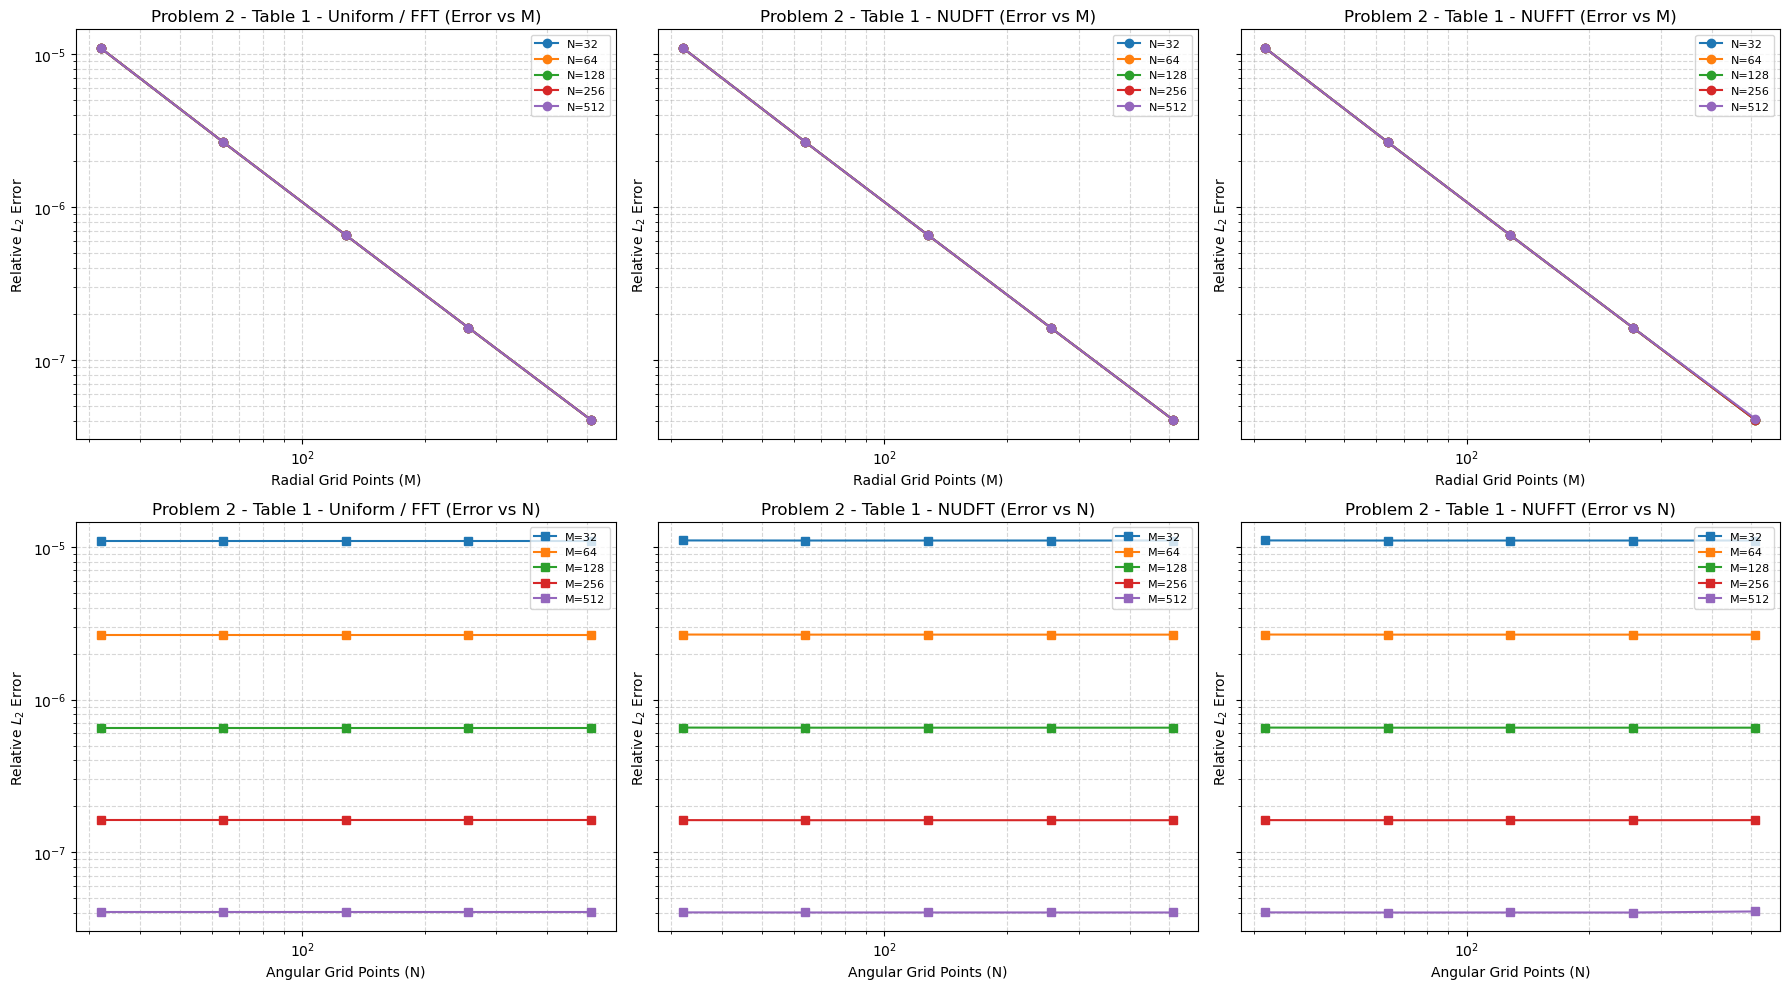

Problem 2 - Table 2 - errors should decrease along rows

Problem 2 - Table 2 (N=32) Accuracy


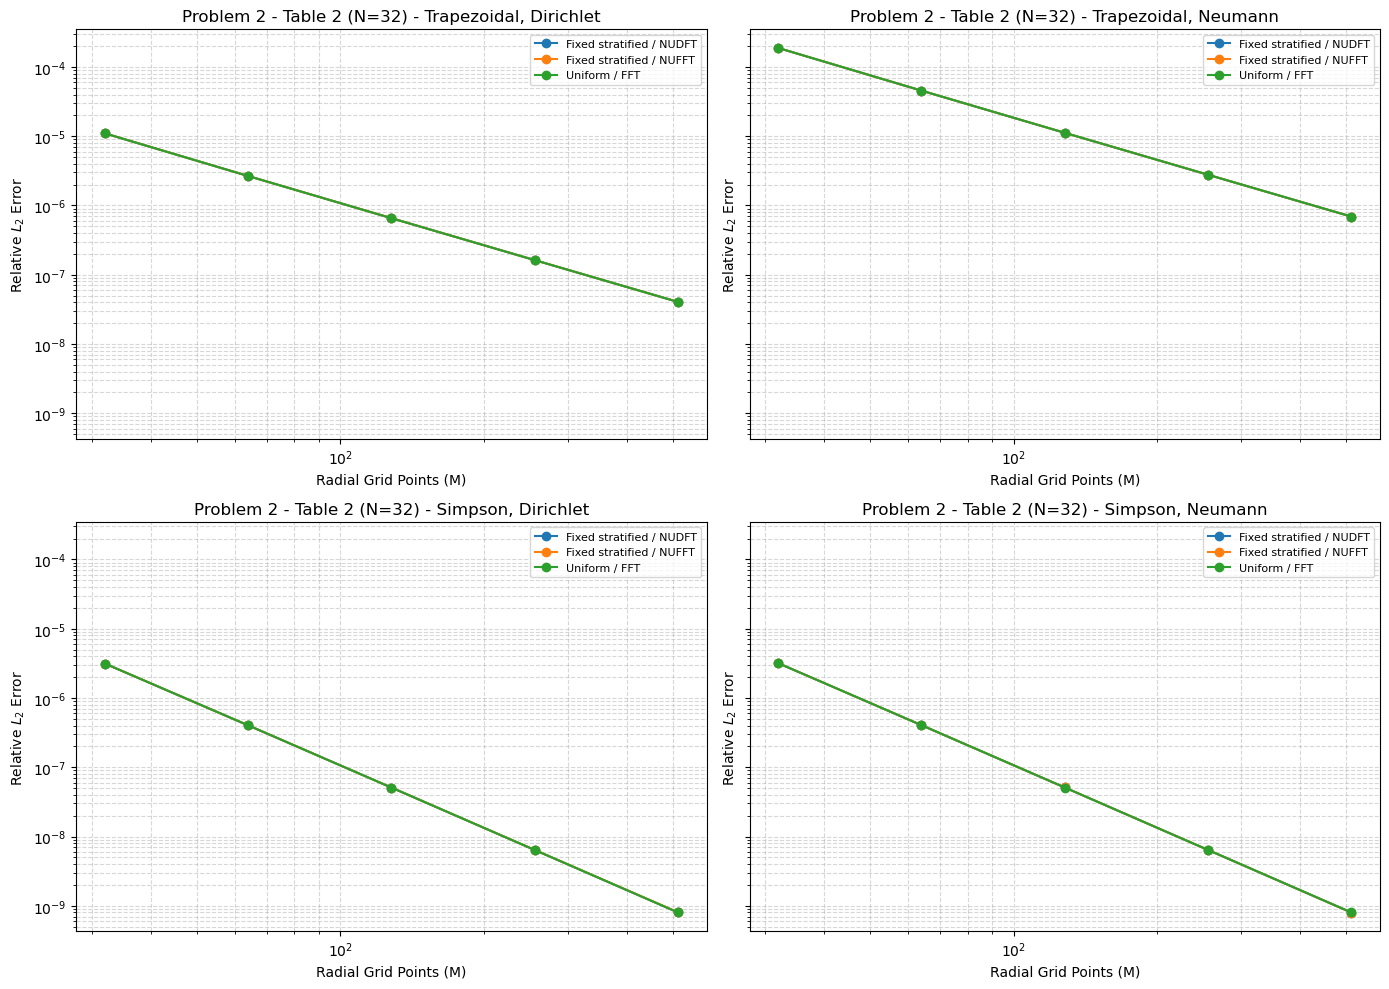

Problem 2 - Table 1 -All errors should be same along rows, and relatively same along columns

Accuracy Comparison (Fixed M=32) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed jittered / NUDFT,Fixed stratified_rand / NUDFT,Fixed jittered / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05
64,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05
128,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05
256,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05
512,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05


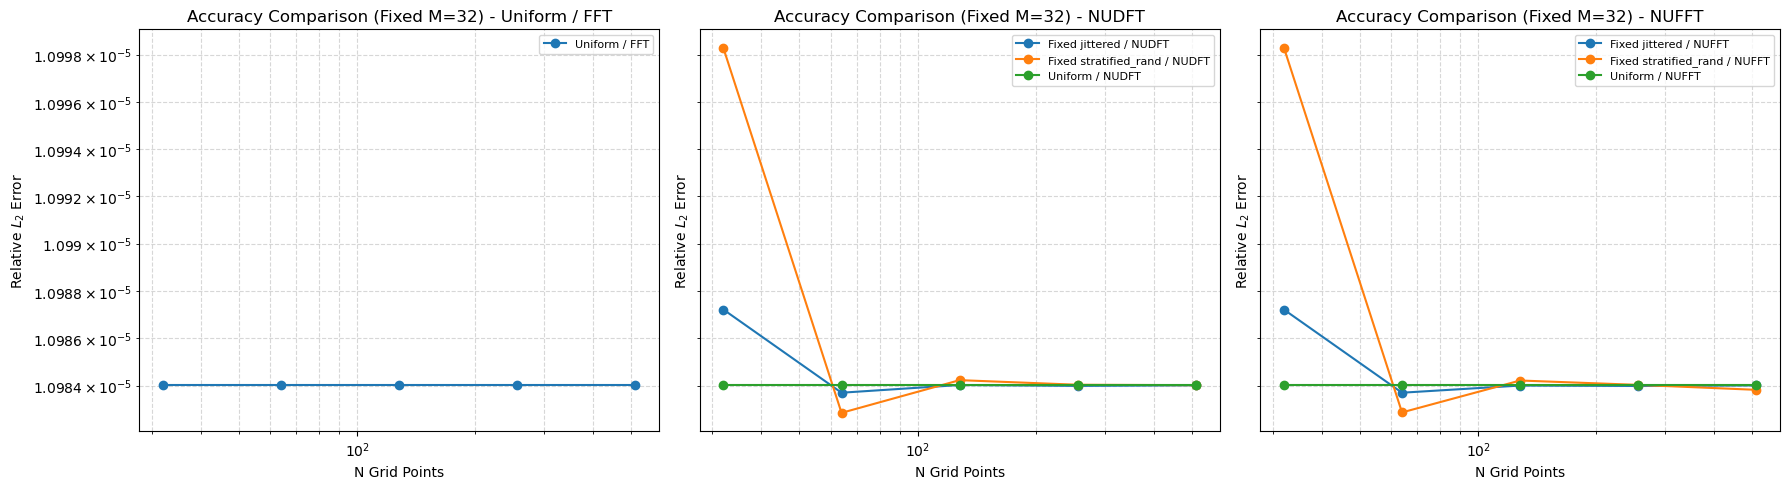

errors for diff meshes getting worse suggests nudft or nufft not accurate
Problem 2 - Table 2 -All errors should decrease along rows, and relatively same along columns

Accuracy Comparison (Fixed N=32) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed jittered / NUDFT,Fixed stratified_rand / NUDFT,Fixed jittered / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07,6.56e-07,6.55e-07,6.56e-07
256,1.62e-07,1.62e-07,1.62e-07,1.62e-07,1.63e-07,1.62e-07,1.63e-07
512,4.04e-08,4.04e-08,4.04e-08,4.05e-08,4.05e-08,4.05e-08,4.05e-08


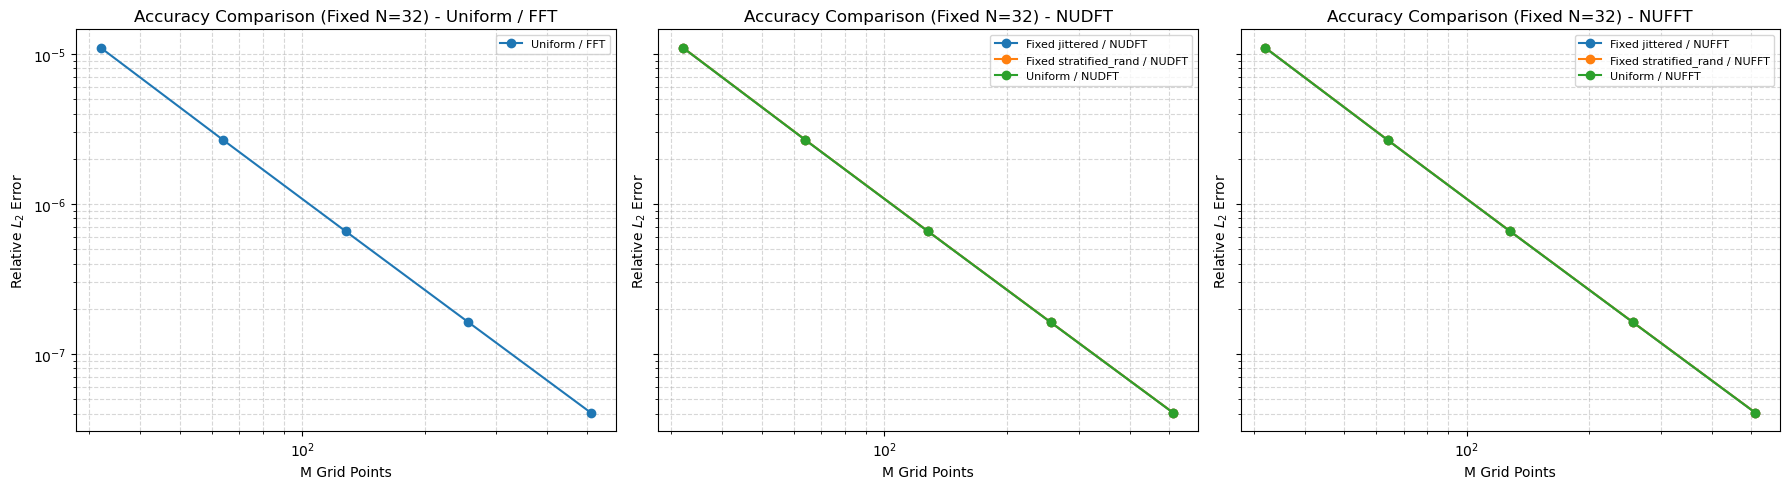

errors for diff meshes getting worse suggests nudft or nufft not accurate


In [4]:
print("--- ACCURACY SECTION ---")


print("Problem 2 - Table 1 - errors should be the same for rows, and decrease along columns. uniform, nudft, and nufft should be same")
render_accuracy(df_p2_t1, index_col="N", columns_col=["label", "M"], title_prefix="Problem 2 - Table 1")
plot_accuracy_table1(df_p2_t1, title_prefix="Problem 2 - Table 1")

print("Problem 2 - Table 2 - errors should decrease along rows")
render_table2_accuracy(df_p2_t2, title_prefix=f"Problem 2 - Table 2 (N={N_fixed_p2})")
plot_accuracy_table2(df_p2_t2, title_prefix=f"Problem 2 - Table 2 (N={N_fixed_p2})")

print("Problem 2 - Table 1 -All errors should be same along rows, and relatively same along columns")
render_accuracy(df_cN, index_col="N", columns_col="label", title_prefix="Accuracy Comparison (Fixed M=32)")
plot_accuracy_comparison(df_cN, index_col="N", title_prefix="Accuracy Comparison (Fixed M=32)")
print("errors for diff meshes getting worse suggests nudft or nufft not accurate")

print("Problem 2 - Table 2 -All errors should decrease along rows, and relatively same along columns")
render_accuracy(df_cM, index_col="M", columns_col="label", title_prefix="Accuracy Comparison (Fixed N=32)")
plot_accuracy_comparison(df_cM, index_col="M", title_prefix="Accuracy Comparison (Fixed N=32)")
print("errors for diff meshes getting worse suggests nudft or nufft not accurate")


# Runtimes

--- RUNTIME SECTION ---
Problem 2 - Table 1 Runtimes (Stratified Rand)

Problem 2 - Table 1 Runtime (s)


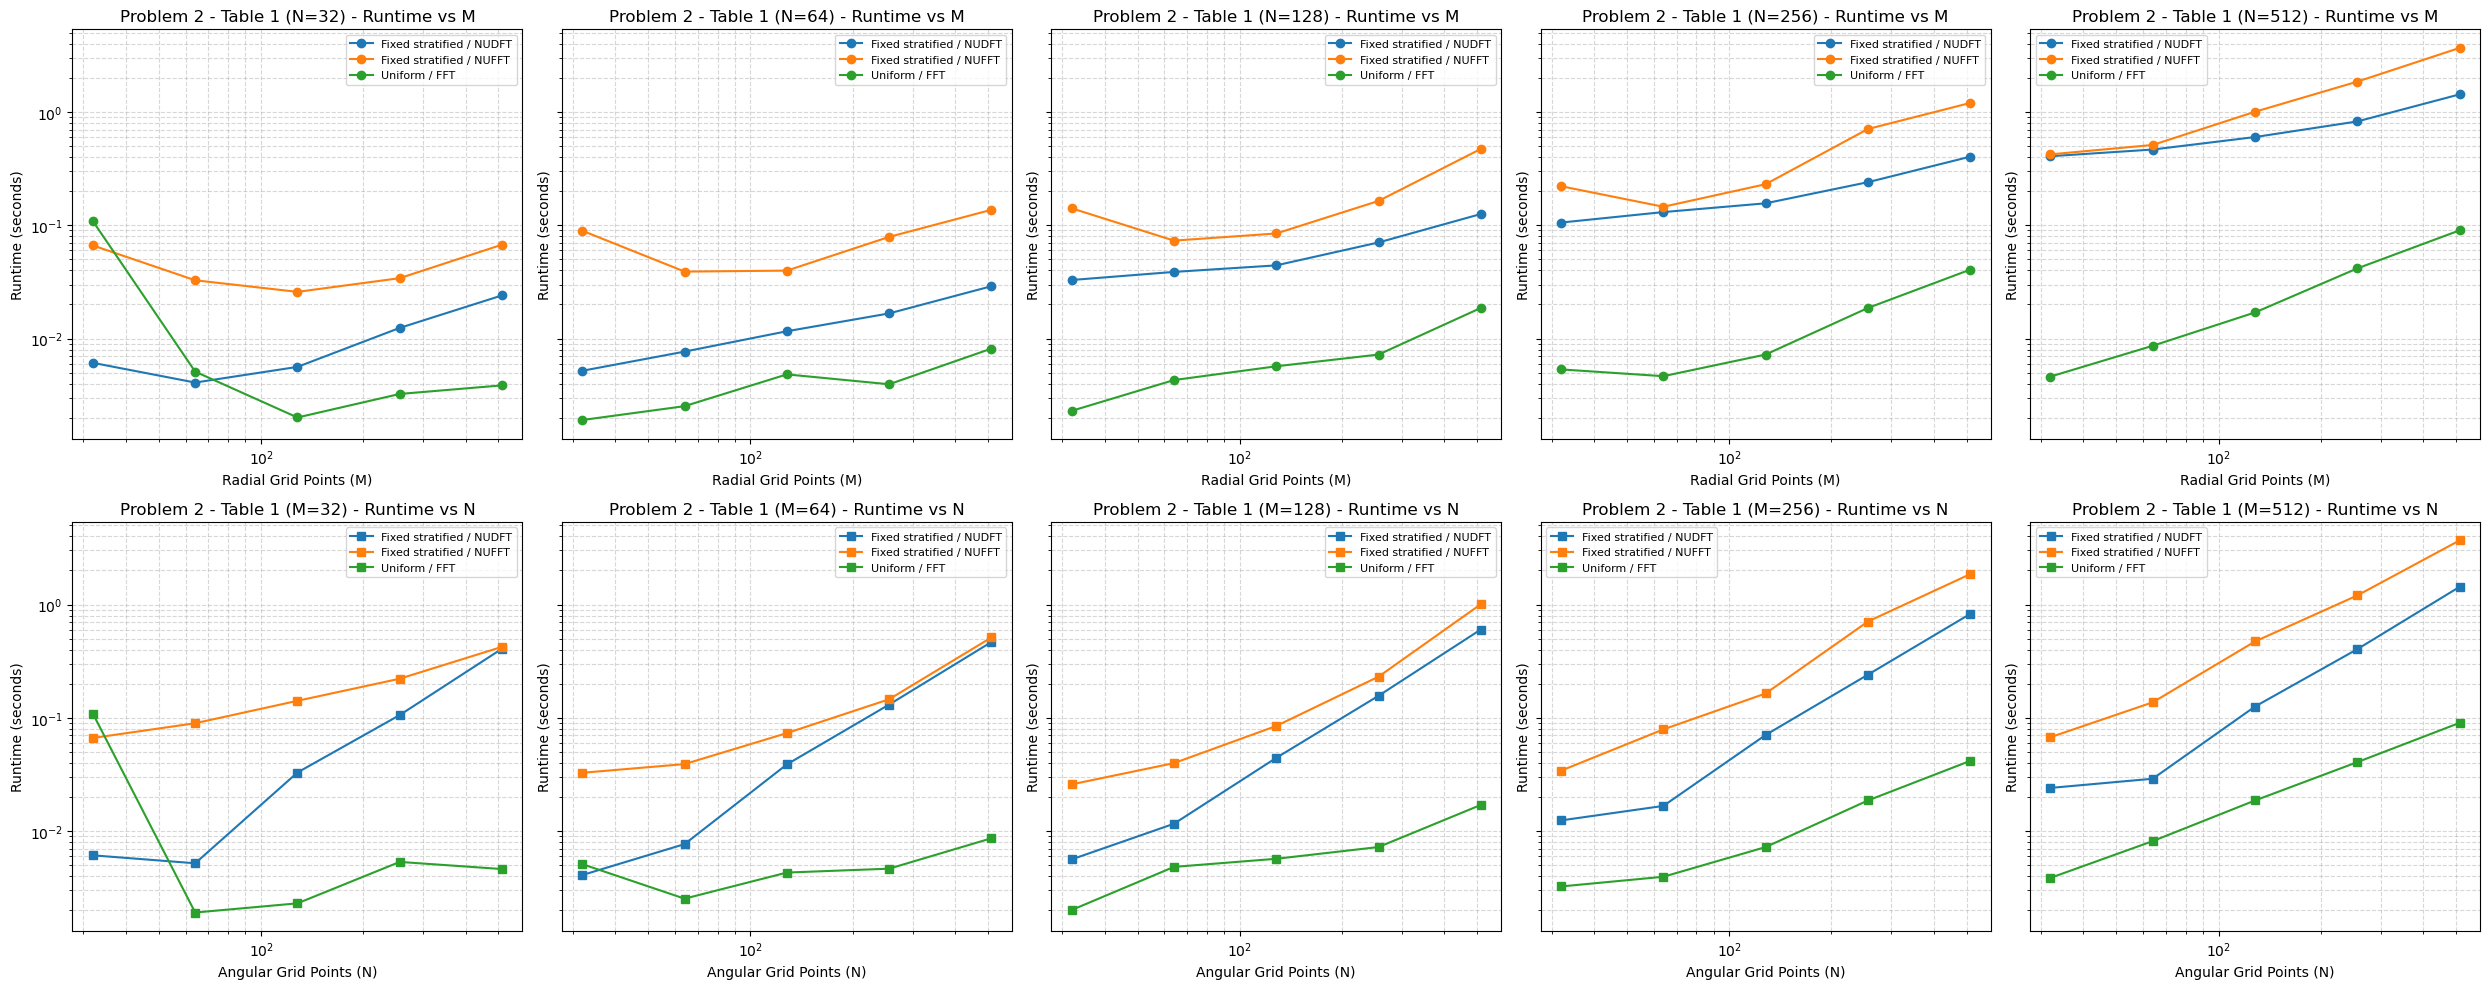

Problem 2 - Table 2 Runtimes (Stratified Rand)

Problem 2 - Table 2 (N=32) Runtime (s)


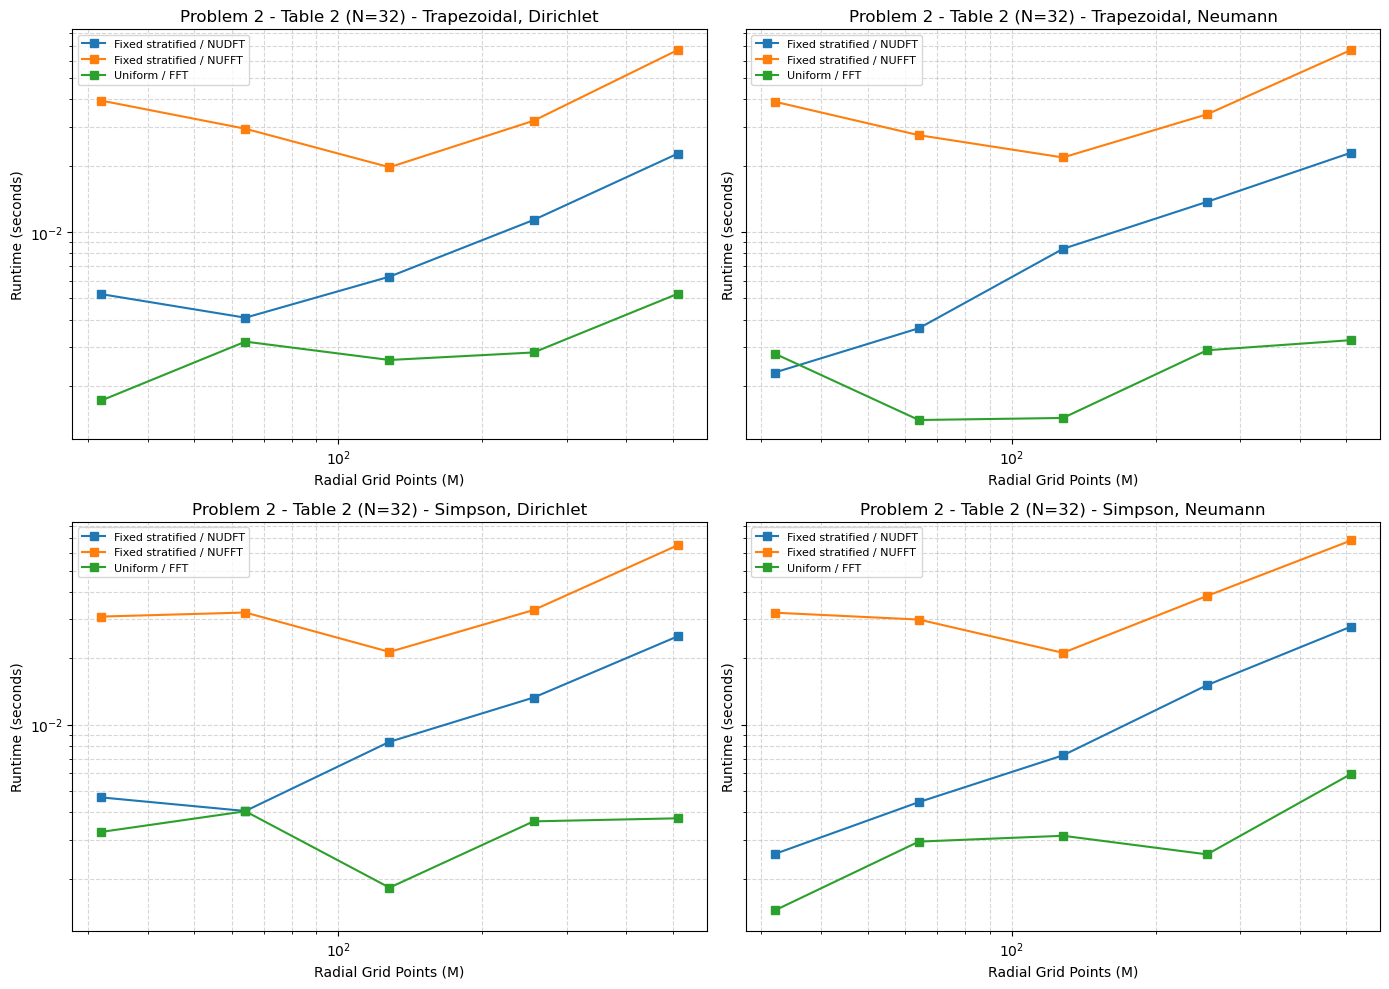

Accuracy Comparison (Fixed M=32) Runtimes

Accuracy Comparison (Fixed M=32) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed jittered / NUDFT,Fixed stratified_rand / NUDFT,Fixed jittered / NUFFT,Fixed stratified_rand / NUFFT
N,,,,,,,
32,0.0025,0.0067,0.0143,0.0046,0.0037,0.0277,0.0289
64,0.0019,0.0034,0.0159,0.0049,0.0034,0.0265,0.0380
128,0.0019,0.0355,0.0309,0.0315,0.0324,0.0457,0.0751
256,0.0043,0.0889,0.0310,0.1046,0.1046,0.0513,0.1391
512,0.0070,0.3407,0.0379,0.3862,0.3995,0.0909,0.2173


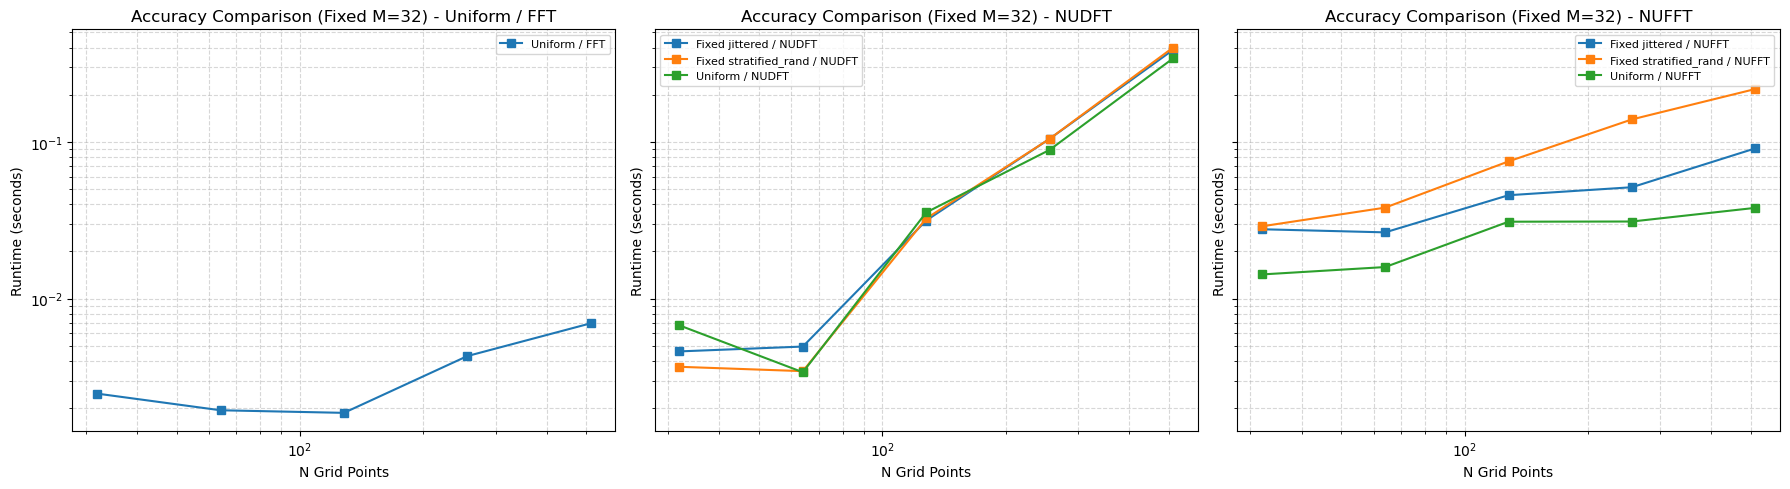

Accuracy Comparison (Fixed N=32) Runtimes

Accuracy Comparison (Fixed N=32) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT,Fixed jittered / NUDFT,Fixed stratified_rand / NUDFT,Fixed jittered / NUFFT,Fixed stratified_rand / NUFFT
M,,,,,,,
32,0.0027,0.0034,0.0115,0.0041,0.0035,0.0285,0.0290
64,0.0018,0.0033,0.0216,0.0042,0.0054,0.0281,0.0291
128,0.0016,0.0053,0.0235,0.0065,0.0055,0.0213,0.0209
256,0.0048,0.0150,0.0322,0.0120,0.0127,0.0288,0.0353
512,0.0038,0.0219,0.0582,0.0287,0.0270,0.0656,0.0626


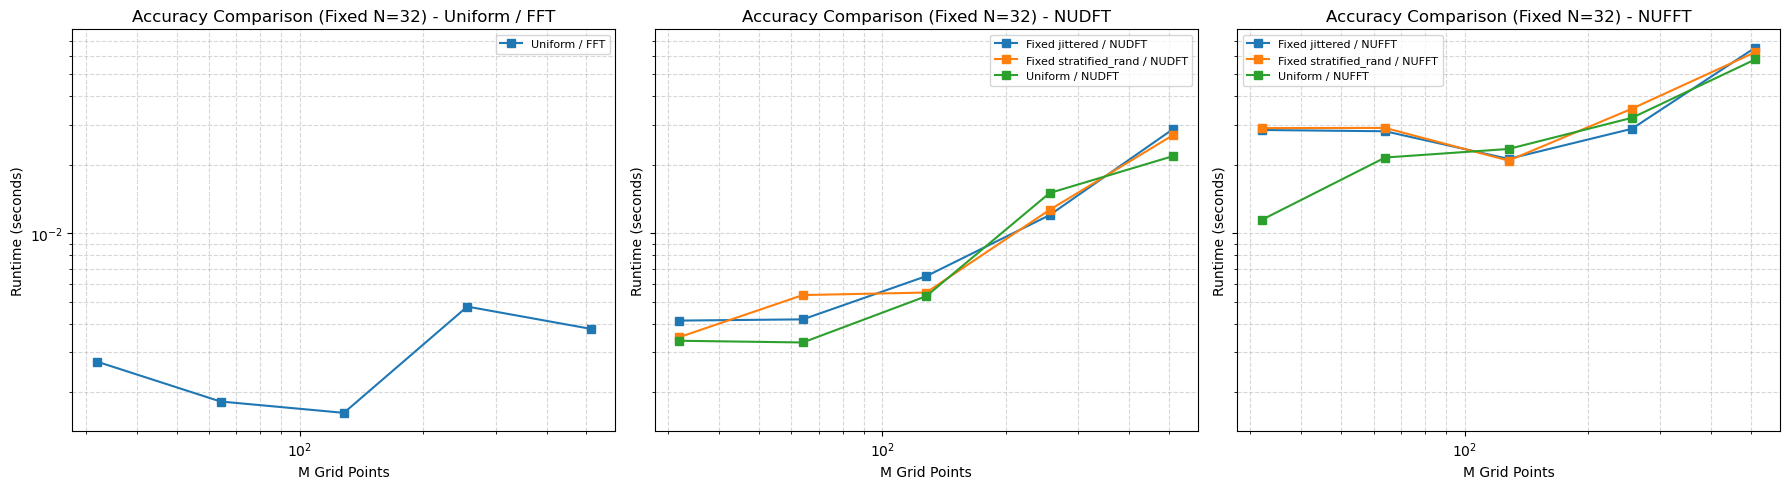

In [5]:
print("--- RUNTIME SECTION ---")


print("Problem 2 - Table 1 Runtimes (Stratified Rand)")
render_runtime(df_p2_t1, index_col="N", columns_col=["label", "M"], title_prefix="Problem 2 - Table 1")
plot_runtime_table1(df_p2_t1, title_prefix="Problem 2 - Table 1")

print("Problem 2 - Table 2 Runtimes (Stratified Rand)")
render_table2_runtime(df_p2_t2, title_prefix=f"Problem 2 - Table 2 (N={N_fixed_p2})")
plot_runtime_table2(df_p2_t2, title_prefix=f"Problem 2 - Table 2 (N={N_fixed_p2})")

print("Accuracy Comparison (Fixed M=32) Runtimes")
render_runtime(df_cN, index_col="N", columns_col="label", title_prefix="Accuracy Comparison (Fixed M=32)")
plot_runtime_comparison(df_cN, index_col="N", title_prefix="Accuracy Comparison (Fixed M=32)")

print("Accuracy Comparison (Fixed N=32) Runtimes")
render_runtime(df_cM, index_col="M", columns_col="label", title_prefix="Accuracy Comparison (Fixed N=32)")
plot_runtime_comparison(df_cM, index_col="M", title_prefix="Accuracy Comparison (Fixed N=32)")
